In [91]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [92]:
import pandas as pd
from scipy.stats import randint, uniform
import numpy as np
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,StratifiedKFold
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams

df = pd.read_csv('/content/smart_manufacturing_data.csv')

In [93]:
print("Shape:",df.shape)

Shape: (100000, 13)


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

In [95]:
df['downtime_risk'].value_counts()

,count
downtime_risk,
0.00,91084
1.00,8904
0.98,3
0.99,3
0.97,2
0.92,1
0.94,1
0.88,1
0.93,1


In [96]:
df.isnull().sum()

,0
timestamp,0
machine_id,0
temperature,0
vibration,0
humidity,0
pressure,0
energy_consumption,0
machine_status,0
anomaly_flag,0
predicted_remaining_life,0


In [97]:
df.describe()

,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


In [98]:
df = df.sort_values(['machine_id','timestamp'])
df.head(5)

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
97,2025-01-01 01:37:00,1,62.59,48.08,60.13,1.62,4.16,1,0,363,Normal,0.0,0
102,2025-01-01 01:42:00,1,70.88,68.67,50.57,1.05,2.36,1,0,111,Normal,0.0,0
133,2025-01-01 02:13:00,1,62.34,72.68,60.47,2.24,4.95,1,0,192,Normal,0.0,0
139,2025-01-01 02:19:00,1,88.03,53.36,50.79,3.08,2.25,1,0,301,Normal,0.0,0
185,2025-01-01 03:05:00,1,79.39,49.44,56.99,2.54,2.76,1,0,127,Normal,0.0,0


In [99]:
df.groupby("maintenance_required")[
    [
        "temperature",
        "vibration",
        "humidity",
        "pressure",
        "energy_consumption",
    ]
].mean()

,temperature,vibration,humidity,pressure,energy_consumption
maintenance_required,,,,,
0,73.609468,49.173089,55.022679,3.001515,2.746174
1,80.748409,53.433540,54.884195,2.995879,2.750692


In [100]:
pd.crosstab(
    df['machine_status'],
    df["maintenance_required"],
    margins=True
)

maintenance_required,0,1,All
machine_status,,,
0,8776,1076,9852
1,71527,8564,80091
2,0,10057,10057
All,80303,19697,100000


# **Missing Value**

In [101]:
df['temperature'] = df.groupby('machine_id')['temperature'].transform(lambda x: x.fillna(x.mean()))
df['vibration'] = df.groupby('machine_id')['vibration'].transform(lambda x: x.fillna(x.mean()))
df['humidity'] = df.groupby('machine_id')['humidity'].transform(lambda x: x.fillna(x.mean()))
df['pressure'] = df.groupby('machine_id')['pressure'].transform(lambda x: x.fillna(x.mean()))
df['energy_consumption'] = df.groupby('machine_id')['energy_consumption'].transform(lambda x: x.fillna(x.mean()))

# **New Feature**

In [102]:
# df["temp_vibration"] = df["temperature"] * df["vibration"]

# machine_temp_mean = df.groupby("machine_id")["temperature"].transform("mean")

# df["temp_deviation"] = (
#     df["temperature"] - machine_temp_mean
# )

# machine_vib_mean = df.groupby("machine_id")["vibration"].transform("mean")

# df["vibration_deviation"] = (
#     df["vibration"] - machine_vib_mean
# )

Analyze Data

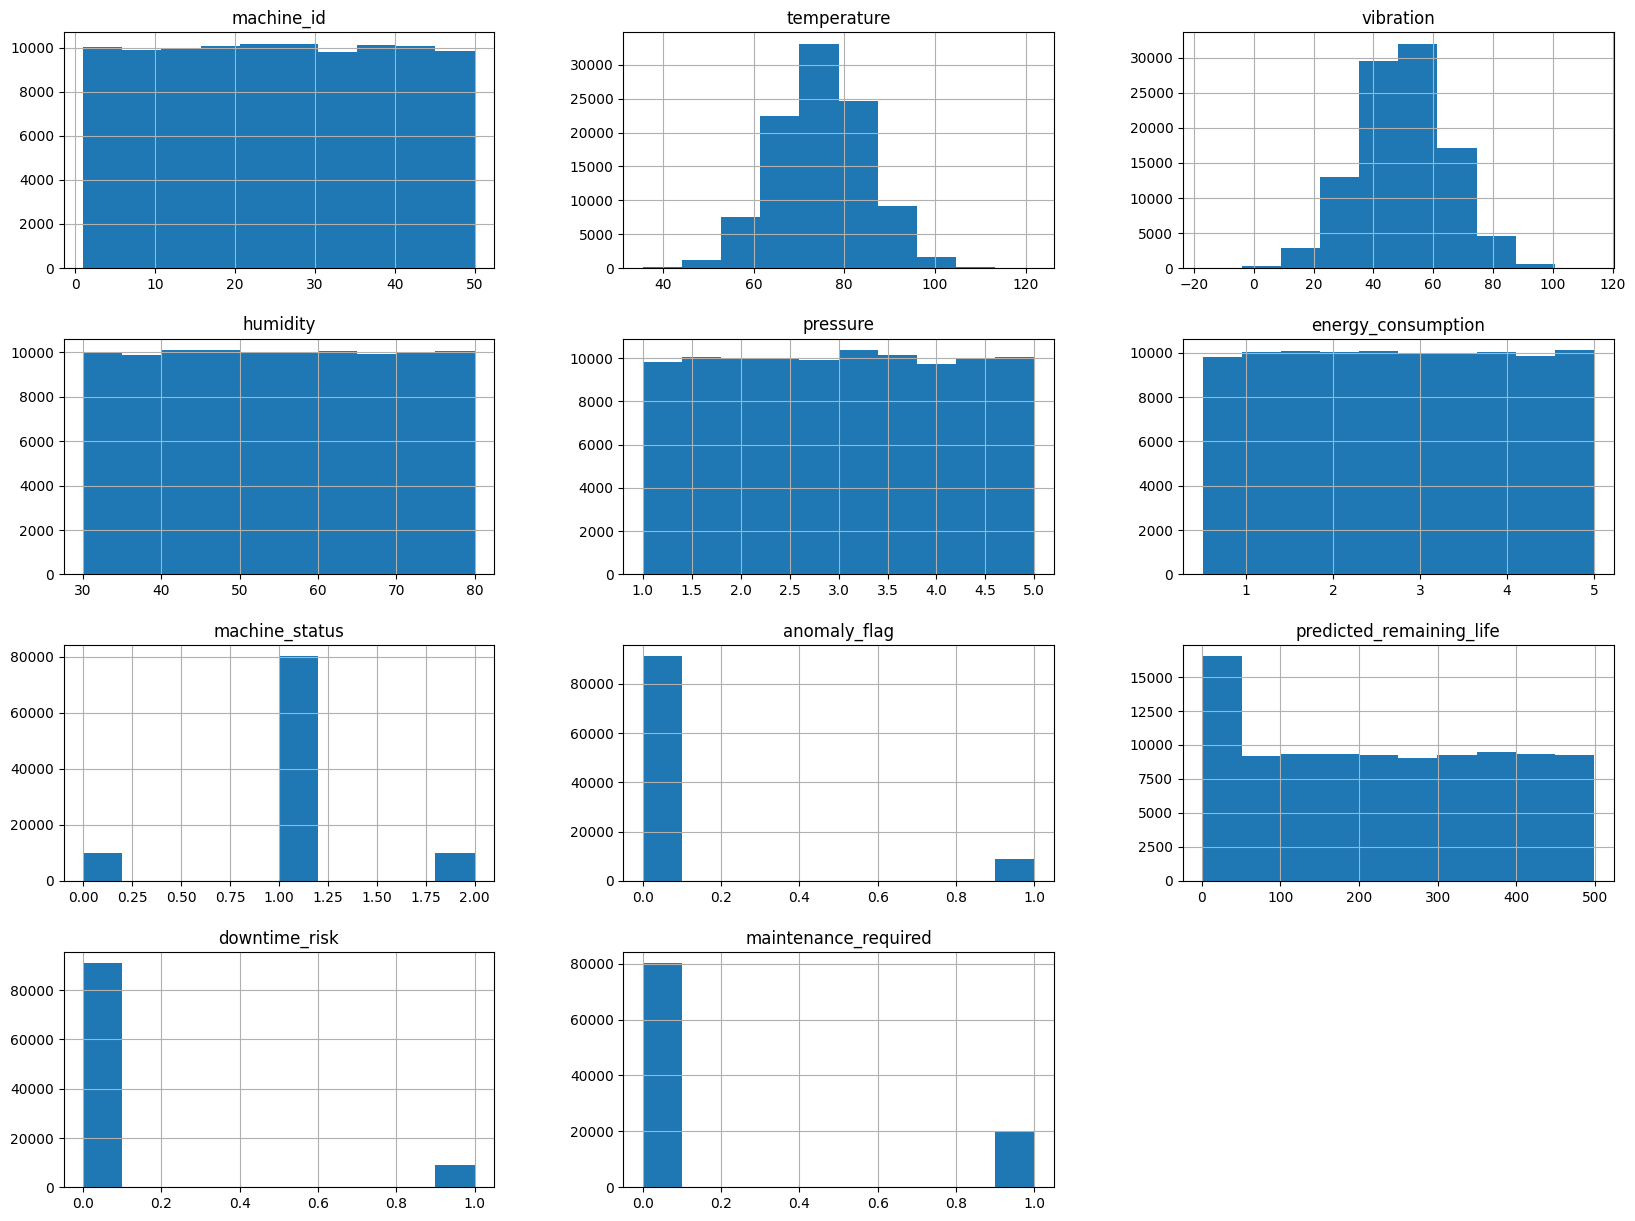

In [103]:
df.hist(figsize=(20, 15))
plt.show()

In [104]:
# numeric_columns = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'temp_vibration', 'temp_deviation', 'vibration_deviation']
numeric_columns = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

# category_columns = ['machine_status', 'anomaly_flag']
category_columns = []

num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

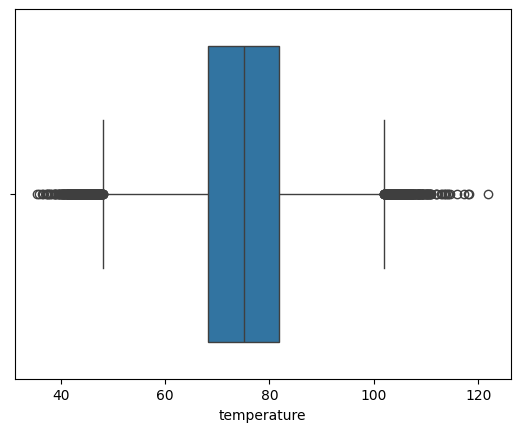

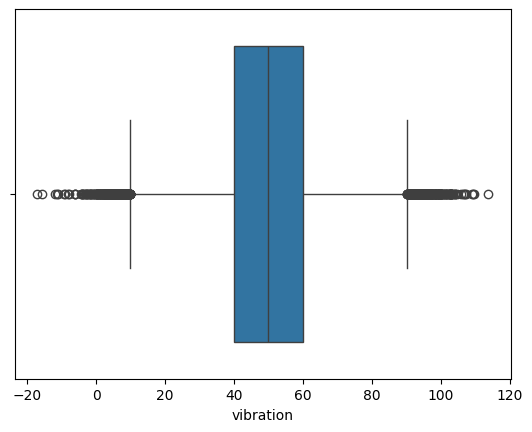

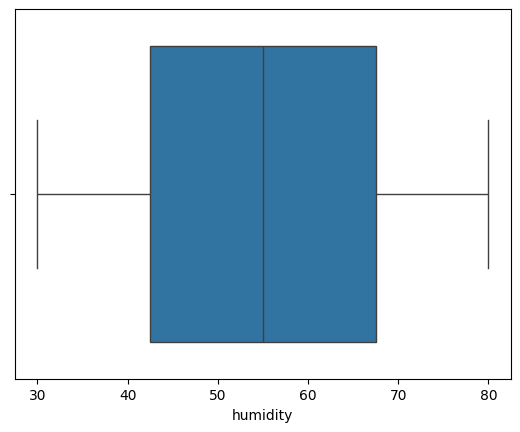

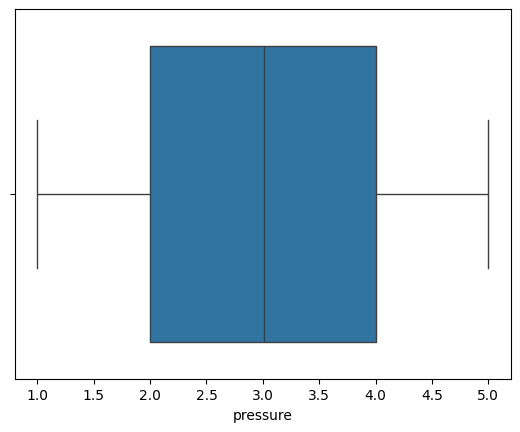

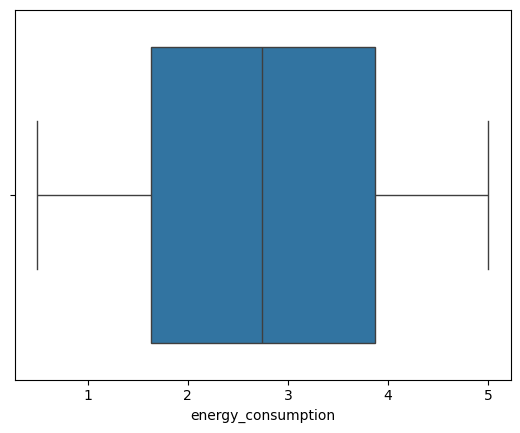

In [105]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

In [106]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_columns),
    ('cat', cat_pipeline, category_columns)
])

<Axes: >

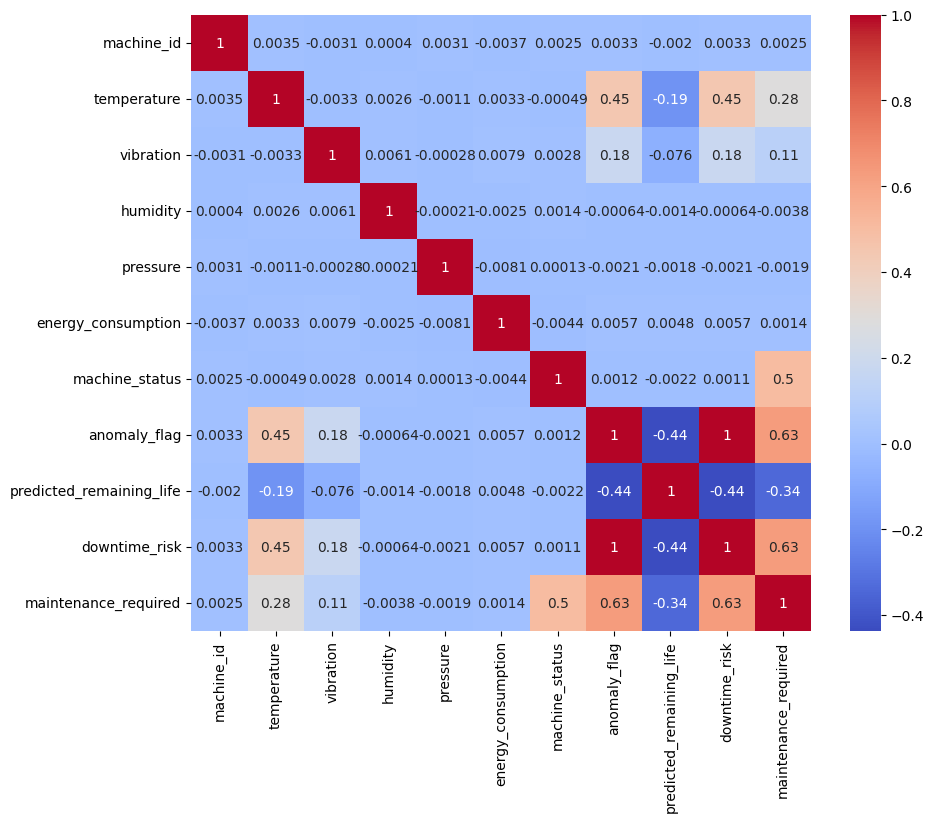

In [107]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

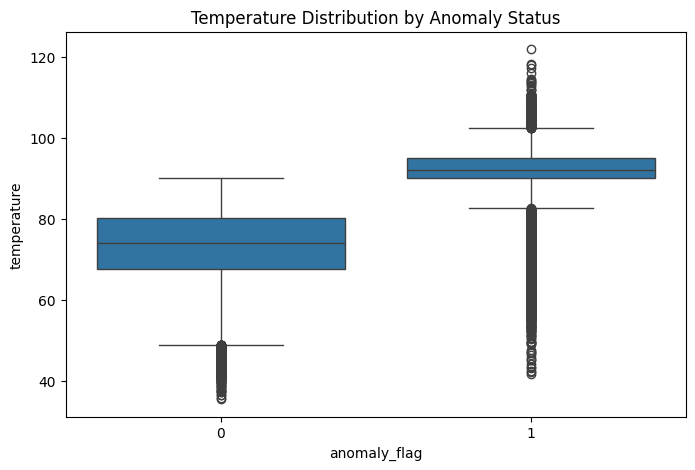

In [108]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="anomaly_flag",
    y="temperature"
)

plt.title("Temperature Distribution by Anomaly Status")
plt.show()

# **Training RandomForest**
Split 70 15 15

In [109]:
X = df[numeric_columns+category_columns]
y = df['maintenance_required']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=56)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(14999.5/85000), random_state=56)

In [110]:
y.value_counts(normalize=True)

,proportion
maintenance_required,
0,0.80303
1,0.19697


In [111]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

In [112]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(70000, 5)
(15000, 5)
(15000, 5)


In [113]:
# rf = RandomForestClassifier(min_samples_split=10, min_samples_leaf=10, max_features=10, n_estimators=200, max_depth=10, random_state=56, criterion='gini')
# rf_pipeline = Pipeline(steps=[
#     ('model', rf)
# ])

In [114]:
# rf_pipeline.fit(X_train_prepared, y_train)

In [115]:
# y_pred = rf_pipeline.predict(X_test_prepared)

In [116]:
# print(metrics.classification_report(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))

# **XGBoost No Tune**

In [117]:
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss"
)

model.fit(
    X_train_prepared,
    y_train
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:32] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:32] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [118]:
y_pred = model.predict(X_test_prepared)

In [119]:
print(metrics.classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     12011
           1       0.99      0.45      0.62      2989

    accuracy                           0.89     15000
   macro avg       0.93      0.72      0.78     15000
weighted avg       0.90      0.89      0.87     15000

[[11994    17]
 [ 1653  1336]]


# **SearchCV**

In [120]:
model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': 'cuda',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': 'hist',
 'validate_parameters': None,
 'verbosity': None}

In [121]:
param_dist = {
    'max_depth': [3,4,5,6],
    'learning_rate': [0.01,0.03,0.05,0.1],
    'min_child_weight': [1,3,5],
}

model = XGBClassifier(
    n_estimators=1000,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    random_state=56
)

rs = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=5,
    n_jobs=1,
    verbose=2,
    random_state=56
)

rs.fit(X_train_prepared, y_train)
print("Best parameter set: "+str(rs.best_params_))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:36] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:36] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.05, max_depth=6, min_child_weight=5; total time=   5.9s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:42] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:42] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.05, max_depth=6, min_child_weight=5; total time=   3.8s


...

[CV] END learning_rate=0.01, max_depth=4, min_child_weight=3; total time=   2.6s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:14] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:14] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.01, max_depth=4, min_child_weight=3; total time=   2.5s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:16] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:16] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best parameter set: {'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01}


In [122]:
best_model = XGBClassifier(
    **rs.best_params_,
    n_estimators=5000,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    early_stopping_rounds=100,
    random_state=56
)

In [123]:
best_model.fit(
    X_train_prepared,
    y_train,
    eval_set=[(X_val_prepared, y_val)],
    verbose=100
)

[0]	validation_0-logloss:0.48926


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:03:21] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:03:21] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-logloss:0.36178
[200]	validation_0-logloss:0.33835
[300]	validation_0-logloss:0.33143
[400]	validation_0-logloss:0.32915
[500]	validation_0-logloss:0.32840
[600]	validation_0-logloss:0.32814
[700]	validation_0-logloss:0.32811
[776]	validation_0-logloss:0.32823


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=100,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=5000, n_jobs=None,
              num_parallel_tree=None, ...)

In [124]:
print(best_model.best_iteration)

676


In [125]:
pred = best_model.predict(X_test_prepared)
print(classification_report(y_test, pred, target_names=['normal', 'abnormal'], digits=4))
print(confusion_matrix(y_test,pred,labels=[0,1]))

              precision    recall  f1-score   support

      normal     0.8789    0.9992    0.9352     12011
    abnormal     0.9926    0.4470    0.6164      2989

    accuracy                         0.8891     15000
   macro avg     0.9358    0.7231    0.7758     15000
weighted avg     0.9016    0.8891    0.8717     15000

[[12001    10]
 [ 1653  1336]]


<Axes: >

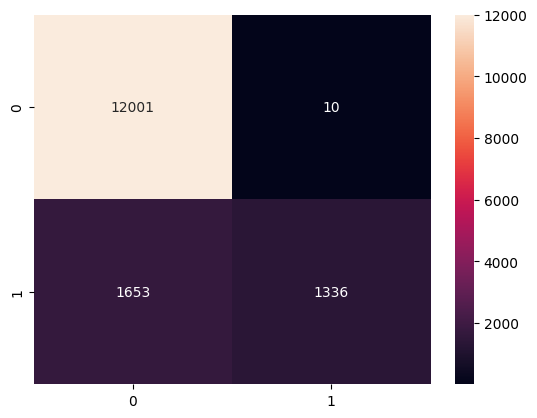

In [126]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

In [127]:
feature_names = preprocessor.get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(15)

importance["group"] = importance["feature"].str.extract(
    r'(temperature|vibration|humidity|pressure|energy_consumption|machine_status|anomaly_flag|predicted_remaining_life|downtime_risk)'
)

grouped = (
    importance.groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped)

group
temperature           0.708059
vibration             0.272404
humidity              0.006817
energy_consumption    0.006523
pressure              0.006196
Name: importance, dtype: float32


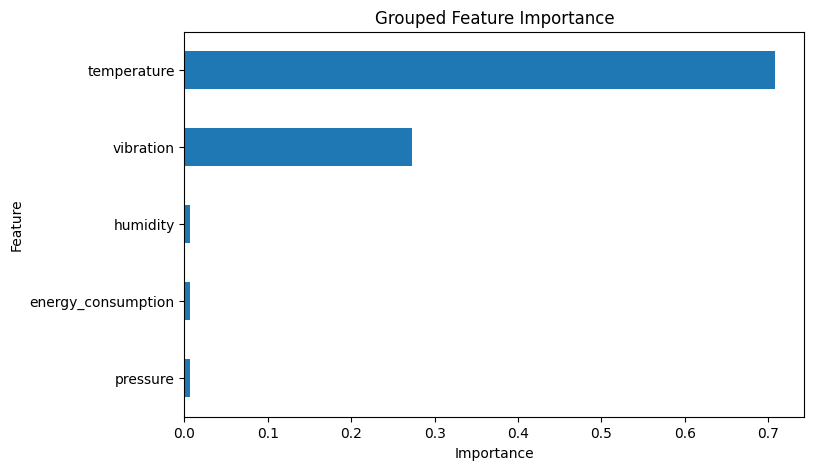

In [128]:
grouped.sort_values().plot.barh(figsize=(8,5))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Grouped Feature Importance")
plt.show()

In [129]:
import joblib

joblib.dump(best_model, "predictive_maintenance_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']